# Baseline English

### Purpose:

Evaluate a pretrained TrOCR model on the English ICDAR test set. This establishes a baseline CER/WER for comparison with later fine-tuning.

### Inputs:
 - IIIT-5K annotations JSON (from 1_Data_Preparation) e.g., Datasets/Annotated_files/iiit5k_test_annotations.json
 - Image files under Datasets/test/...

### Outputs:
 - Printed baseline metrics (CER, WER)

### Method summary:
 - Load TrOCR processor + model
 - For each image: preprocess -> model.generate -> decode text
 - Compare predictions to ground-truth with CER/WER

In [1]:
#!pip install transformers jiwer pillow torch torchvision torchaudio --quiet


In [13]:
import os
import json
import time
from PIL import Image
import pandas as pd
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from jiwer import cer, wer

In [3]:
## Path Setup

Base_dir = ".."
Annotation_dir = os.path.join(Base_dir, "Datasets", "Annotated_files")

train_ann = os.path.join(Annotation_dir, "iiit5k_train_annotations.json")
test_ann  = os.path.join(Annotation_dir, "iiit5k_test_annotations.json")

#print(os.path.exists(train_ann), train_ann)
#print(os.path.exists(test_ann), test_ann)

In [4]:
## Load Annotations into dataframes

train_df = pd.read_json(train_ann)
test_df  = pd.read_json(test_ann)

len(train_df), len(test_df), train_df.head()


(1156,
 331,
                        image_path     label
 0  ../Datasets/train/word/1/1.jpg      self
 1  ../Datasets/train/word/1/2.jpg  adhesive
 2  ../Datasets/train/word/1/3.jpg   address
 3  ../Datasets/train/word/1/4.jpg    labels
 4  ../Datasets/train/word/1/5.jpg        36)

intelligent ../Datasets/train/word/8/742.jpg


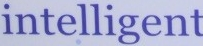

In [5]:
## Check if it is printing right

row = train_df.sample(1, random_state=3).iloc[0]
print(row["label"], row["image_path"])
display(Image.open(row["image_path"]).convert("RGB"))

## Load Pretrained TrOCR Model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
# TrOCR is a VisionEncoderDecoderModel:
# - encoder processes the image
# - decoder generates the text token-by-token

model_name = "microsoft/trocr-base-printed"
processor = TrOCRProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
model.eval()

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [8]:
def predict_word_from_path(img_path: str) -> str:
    ## Load an image and convert to model-ready pixel_values tensor.
    image = Image.open(img_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return pred

GT: WALK
Pred: WALK


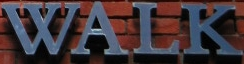

In [9]:
sample = test_df.sample(1, random_state=200).iloc[0]
print("GT:", sample["label"])
print("Pred:", predict_word_from_path(sample["image_path"]))
display(Image.open(sample["image_path"]).convert("RGB"))

## Baseline evaluation (CER + Word accuracy)

In [10]:
# CER (Character Error Rate): edit distance at character level / num chars
# WER (Word Error Rate): edit distance at word level / num words

def evaluate_baseline(df, max_samples=500):
    refs, hyps = [], []
    t0 = time.time()

    sub_df = df.sample(min(max_samples, len(df)), random_state=42).reset_index(drop=True)

    for i, row in sub_df.iterrows():
        gt = row["label"]
        pred = predict_word_from_path(row["image_path"])

        refs.append(gt)
        hyps.append(pred)

        if (i + 1) % 50 == 0:
            print(f"{i+1}/{len(sub_df)} done")

    char_err = cer(refs, hyps)
    word_err = wer(refs, hyps)
    word_acc = 1 - word_err
    elapsed = time.time() - t0

    return {
        "num_samples": len(sub_df),
        "cer": char_err,
        "word_error_rate": word_err,
        "word_accuracy": word_acc,
        "time_seconds": elapsed,
    }, refs, hyps


In [11]:
baseline_metrics, refs, hyps = evaluate_baseline(test_df, max_samples=500)
baseline_metrics

50/331 done
100/331 done
150/331 done
200/331 done
250/331 done
300/331 done


{'num_samples': 331,
 'cer': 0.5421979356405586,
 'word_error_rate': 0.6072507552870091,
 'word_accuracy': 0.3927492447129909,
 'time_seconds': 28.63152503967285}

In [12]:
for gt, pred in list(zip(refs, hyps))[:50]:
    print(f"GT: {gt:20s} | Pred: {pred}")


GT: Office               | Pred: OFFICE
GT: the                  | Pred: THE
GT: Student              | Pred: STUDENT
GT: Community            | Pred: CASHIER
GT: SUPPLIES             | Pred: SUPPLIES
GT: fish                 | Pred: FISH
GT: &                    | Pred: 8
GT: P                    | Pred: P
GT: cut                  | Pred: CUT
GT: 3                    | Pred: 3
GT: Do                   | Pred: DO
GT: OPPORTUNITIES        | Pred: OPPORTUNITIES
GT: out                  | Pred: OUT
GT: IS                   | Pred: IS
GT: over                 | Pred: OVER
GT: HEALTHY              | Pred: HEALTHY
GT: FINAL                | Pred: FINAL
GT: week                 | Pred: WEEK
GT: you                  | Pred: YOU
GT: Â£9                  | Pred: 69
GT: 10                   | Pred: 1 0
GT: available            | Pred: AVAILABLE
GT: Bookshop             | Pred: BOOKSHOP
GT: CLEANED              | Pred: CLEANED
GT: CITY                 | Pred: CITY
GT: H                    | Pred: 